Example Plots for Simulated Annealing

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Parameters
num_runs = 2

# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 1000
end_temp = 1
max_temp_iterations = 101

[[WindowsPath('data/brute_force/test/candidate_space_2_candidates_40_buses_1_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/test/candidate_space_2_candidates_40_buses_2_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/test/candidate_space_2_candidates_40_buses_3_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/test/candidate_space_2_candidates_40_buses_4_seed_2026-04-07_17-25-28.csv')], [WindowsPath('data/brute_force/test/candidate_space_4_candidates_40_buses_1_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/test/candidate_space_4_candidates_40_buses_2_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/test/candidate_space_4_candidates_40_buses_3_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/test/candidate_space_4_candidates_40_buses_4_seed_2026-04-07_17-25-29.csv')], [WindowsPath('data/brute_force/test/candidate_space_8_candidates_40_buses_1_seed_2026-04-07_17-25-28.csv'), WindowsPath('data/brute_force/t

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import re

directory = './data/brute_force/test'
data_files = [p for p in Path(directory).glob("*.csv") if p.is_file()]
candidate_dims = [(np.log2(int(re.search(string=str(p.name), pattern=r'_(\d*)_(candidates|instances)').group(1))), p) for p in data_files]

df = pd.DataFrame(data=candidate_dims, columns=['dims','paths'])
df = df.groupby('dims')['paths'].agg(list).reset_index()

In [ ]:
problem_sizes = df['dims'].tolist()
brute_force_data_paths = df['paths'].tolist()
boundss = df['dims'].apply(lambda x: int(x) * [(0, 1)]).tolist()

In [6]:
import pandas as pd
import numpy as np

brute_force_data = [[pd.read_csv(p) for p in path] for path in brute_force_data_paths]
loss_spaces = [np.array([d['loss'] for d in data]) for data in brute_force_data]

In [7]:
from cl_optimizer import SimulatedAnnealing
sim_annss = [[[
        SimulatedAnnealing(
        lookup_table=d,
        bounds=bounds,
    ) for _ in range(num_runs)
] for d in data] for data, bounds in zip(brute_force_data, boundss, strict=True)] # a sim_ann per problem size and instance

[[[<cl_optimizer.SimulatedAnnealing object at 0x0000015BA5105CA0>, <cl_optimizer.SimulatedAnnealing object at 0x0000015BFF4646B0>], [<cl_optimizer.SimulatedAnnealing object at 0x0000015B928AB110>, <cl_optimizer.SimulatedAnnealing object at 0x0000015B928AB0E0>], [<cl_optimizer.SimulatedAnnealing object at 0x0000015B862CE6C0>, <cl_optimizer.SimulatedAnnealing object at 0x0000015B862CEB70>], [<cl_optimizer.SimulatedAnnealing object at 0x0000015BA514F290>, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA514F2C0>]], [[<cl_optimizer.SimulatedAnnealing object at 0x0000015BA5152060>, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA51521E0>], [<cl_optimizer.SimulatedAnnealing object at 0x0000015BA5153710>, <cl_optimizer.SimulatedAnnealing object at 0x0000015B9286DDC0>], [<cl_optimizer.SimulatedAnnealing object at 0x0000015B9286DE80>, <cl_optimizer.SimulatedAnnealing object at 0x0000015B9286F170>], [<cl_optimizer.SimulatedAnnealing object at 0x0000015B9286F110>, <cl_optimizer.Simulat

In [10]:
from joblib import Parallel, delayed
from parallelization import construct_parallelization_arg_list, get_execute_sim_ann

resultsss = []
for sim_ann_list in sim_annss:
    resultss = []
    for sim_anns in sim_ann_list:
        arg_list = construct_parallelization_arg_list(sim_anns, depth=max_temp_iterations, step=10, batch_size=8)

        print(f"Preparing to execute {len(arg_list)} in parallel.")
        results = np.array(
            Parallel(n_jobs=-1, verbose=11)(
            delayed(get_execute_sim_ann(init_temp, end_temp))(s_id, sim_ann, temp_iterations) for (s_id, sim_ann), temp_iterations in arg_list)
        )

        resultss.append(results)
    resultsss.append(resultss)

[((0, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA5105CA0>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101])), ((1, <cl_optimizer.SimulatedAnnealing object at 0x0000015BFF4646B0>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101]))]
Preparing to execute 2 in parallel.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[((0, <cl_optimizer.SimulatedAnnealing object at 0x0000015B928AB110>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101])), ((1, <cl_optimizer.SimulatedAnnealing object at 0x0000015B928AB0E0>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101]))]
Preparing to execute 2 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[((0, <cl_optimizer.SimulatedAnnealing object at 0x0000015B862CE6C0>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101])), ((1, <cl_optimizer.SimulatedAnnealing object at 0x0000015B862CEB70>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101]))]
Preparing to execute 2 in parallel.


...

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   43.9s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   44.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[((0, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA5157710>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101])), ((1, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA5157770>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101]))]
Preparing to execute 2 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   47.0s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   47.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[((0, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA51577D0>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101])), ((1, <cl_optimizer.SimulatedAnnealing object at 0x0000015BA5157830>), array([  1,  11,  21,  31,  41,  51,  61,  71,  81,  91, 101]))]
Preparing to execute 2 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   45.1s
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   45.4s finished


In [11]:
result_tensor = np.stack(resultsss, axis=0).squeeze()

In [12]:
indices = np.argsort(result_tensor[..., 1], axis=2) # sort by temp. iterations (parallelization does not guarantee order)
indices_expanded = np.expand_dims(indices, axis=-1)
result_tensor = np.take_along_axis(result_tensor, indices_expanded, axis=2)

In [13]:
result_tensor.shape # should be a 5-tuple: (n_problem_sizes, n_instances_per_problem_size, n_runs_per_instance, n_temp_iter_steps, 3)

(20, 4, 2, 11, 3)

In [14]:
loss_tensor = result_tensor[:, :, :, :, 2] # loss has index 2 in last dim

In [15]:
from datetime import datetime

temp_iterations = result_tensor[0, 0, 0, :, 1].astype(int)
flattened_losses = loss_tensor.reshape(result_tensor.shape[3], -1).T

cols = [f'loss (temperature={int(temp)})' for temp in temp_iterations]
df = pd.DataFrame(flattened_losses, columns=cols)
df["data path"] = np.repeat(brute_force_data_paths, num_runs)
df.to_csv(f'data/simulated_annealing/summary_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv')

In [61]:
from metrics import raar

avg_loss_runs = loss_tensor.mean(axis=2)
raars = np.array([[[raar(avg, loss_spaces[i][j, :]) for avg in avg_loss] for j, avg_loss in enumerate(avg_loss_runs_per_problem_size)] for i, avg_loss_runs_per_problem_size in enumerate(avg_loss_runs)])
mean_raar = raars.mean(axis=(0, 1))
std_raar = raars.std(axis=(0, 1))

(20, 4, 11)
(20, 4, 11)


<Axes: xlabel='temperature iterations', ylabel='RAAR'>

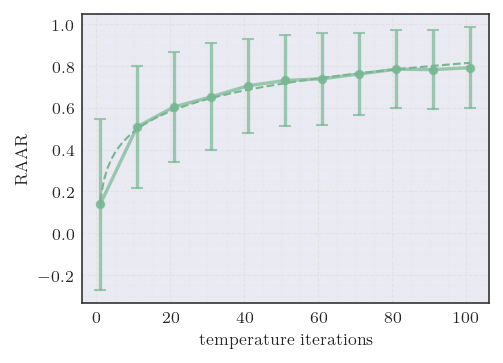

In [32]:
import styling
import matplotlib.pyplot as plt
import seaborn as sns

styling.set_my_style()

df = pd.DataFrame()
df["temperature iterations"] = temp_iterations
df["RAAR"] = mean_raar.squeeze()
df["RAAR_std"] = std_raar.squeeze()

palette = styling.shades(6, 4)[1:]
palette = sns.color_palette("crest", 5)


fig, ax = styling.subplots(figsize=(3.5, 2.5))

plt.plot(
    df["temperature iterations"],
    df["RAAR"],
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax.errorbar(
    x=df["temperature iterations"],
    y=df["RAAR"],
    yerr=df["RAAR_std"],
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)

sns.regplot(x=df["Temperature Iterations"], y=df["RAAR"], color=palette[0], ax=ax, line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)

In [40]:
min_losses = np.array([spaces.min(axis=1) for spaces in loss_spaces])
min_loss_candidates = np.array([[d[d['loss'] == m]['candidate'] for d, m in zip(data, min_loss)] for data, min_loss in zip(brute_force_data, min_losses)]).squeeze()

In [42]:
optimal_candidates_found = np.count_nonzero(loss_tensor ==  min_losses.reshape(min_losses.shape[0], min_losses.shape[1], 1, 1), axis=2)
p_star = (optimal_candidates_found.T / loss_tensor.shape[-1]).T

In [44]:
from metrics import tts_p
tts_ps = np.apply_along_axis(tts_p, axis=-1, arr=p_star)

In [45]:
mask = np.any(np.isfinite(tts_ps), axis=(0, 1))
non_inf_tts_ps = tts_ps[..., mask]

In [47]:
finite_mask = np.any(np.isfinite(non_inf_tts_ps), axis=-1, keepdims=True)

masked = np.ma.masked_invalid(non_inf_tts_ps)
mean_tts_ps = masked.mean(axis=(0, 1)).data
std_tts_ps = masked.std(axis=(0, 1)).data

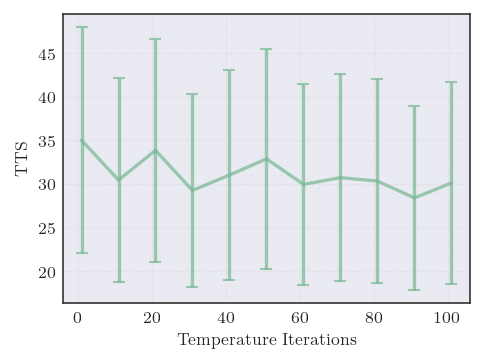

In [60]:
from matplotlib import pyplot as plt

fig, ax = styling.subplots(figsize=(3.5, 2.5))

ax.plot(
    temp_iterations[mask],
    mean_tts_ps,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

ax.errorbar(
    temp_iterations[mask],
    y=mean_tts_ps,
    yerr=std_tts_ps,
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)
plt.ylabel('TTS')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)

In [50]:
masked = np.ma.masked_invalid(non_inf_tts_ps)
min_tts = masked.min(axis=-1).squeeze().data
avg_min_tts = min_tts.mean(axis=-1)
std_min_tts = min_tts.std(axis=-1)

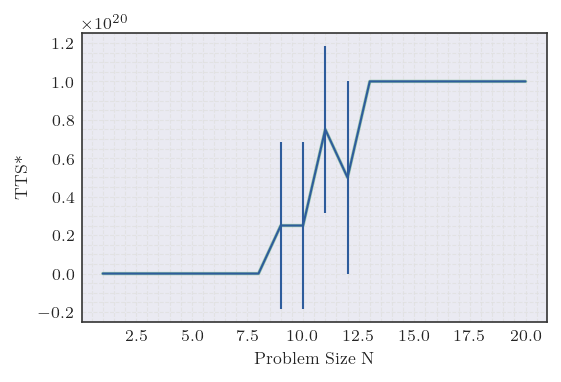

In [59]:
plt.plot(
    problem_sizes,
    avg_min_tts,
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)

plt.errorbar(
    problem_sizes,
    y=avg_min_tts,
    yerr=std_min_tts,
)
plt.ylabel('TTS*')
plt.xlabel('Problem Size N')
plt.grid(visible=True)